In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [4]:
iris_df.drop(['sepal length (cm)', 'sepal width (cm)'], axis=1)

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


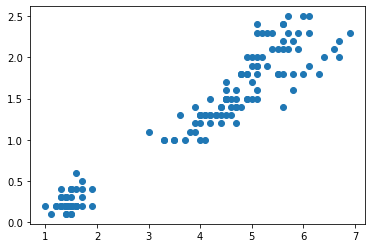

In [8]:
plt.scatter(iris_df['petal length (cm)'], iris_df['petal width (cm)'])

In [11]:
km = KMeans(n_clusters=3)

In [12]:
y_predicted = km.fit_predict(iris_df[['petal length (cm)', 'petal width (cm)']])
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [13]:
iris_df['clusters'] = y_predicted
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clusters
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Text(0, 0.5, 'petal width (cm)')

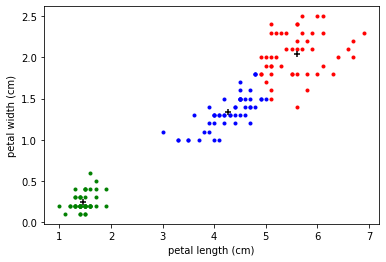

In [14]:
iris_df0 = iris_df[iris_df.clusters==0]
iris_df1 = iris_df[iris_df.clusters==1]
iris_df2 = iris_df[iris_df.clusters==2]

plt.scatter(iris_df0['petal length (cm)'], iris_df0['petal width (cm)'], color='green', marker='.')
plt.scatter(iris_df1['petal length (cm)'], iris_df1['petal width (cm)'], color='red', marker='.')
plt.scatter(iris_df2['petal length (cm)'], iris_df2['petal width (cm)'], color='blue', marker='.')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='black', marker='+')

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')

In [15]:
km.cluster_centers_

array([[1.462     , 0.246     ],
       [5.59583333, 2.0375    ],
       [4.26923077, 1.34230769]])

In [16]:
km.inertia_

31.371358974358984

In [25]:
k_range = range(10)
SSE = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(iris_df[['petal length (cm)', 'petal width (cm)']])
    SSE.append(km.inertia_)

C:\Users\CHUFESS\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:191: RuntimeWarning: divide by zero encountered in log
  n_local_trials = 2 + int(np.log(n_clusters))


OverflowError: cannot convert float infinity to integer

In [21]:
iris_df['petal length (cm)']

0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: petal length (cm), Length: 150, dtype: float64